In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

---

# Voltímetro:

Características do Galvanômetro:

In [2]:
VG = 30.2 # mV
VG = VG * 1e-3 # V
RG = 11.6 # Ohm

IG = VG / RG # A

print(f'Corrente do Galvanômetro: {IG*1e3:.4f} mA')

Corrente do Galvanômetro: 2.6034 mA


Resistência e amperagem esperadas para medir diversas voltagens:

In [3]:
Vvolt = [1.06, 10.1, 20.1, 30.6]

R_ideal = [((v/VG)-1)*RG for v in Vvolt] 

I_ideal = [v/r for v, r in zip(Vvolt, R_ideal)]

df = pd.DataFrame({'V': Vvolt, 'R(kOhm)': R_ideal, 'I(mA)': I_ideal})
df['R(kOhm)'] = df['R(kOhm)'].apply(lambda x: f'{x*1e-3:.4f}')
df['I(mA)'] = df['I(mA)'].apply(lambda x: f'{x*1e3:.4f}')

df

,V,R(kOhm),I(mA)
0,1.06,0.3956,2.6798
1,10.10,3.8679,2.6113
2,20.10,7.7089,2.6074
3,30.60,11.7420,2.6060


Equação de ajuste linear

Coeficientes da reta: A = 0.3841, B = -0.0115


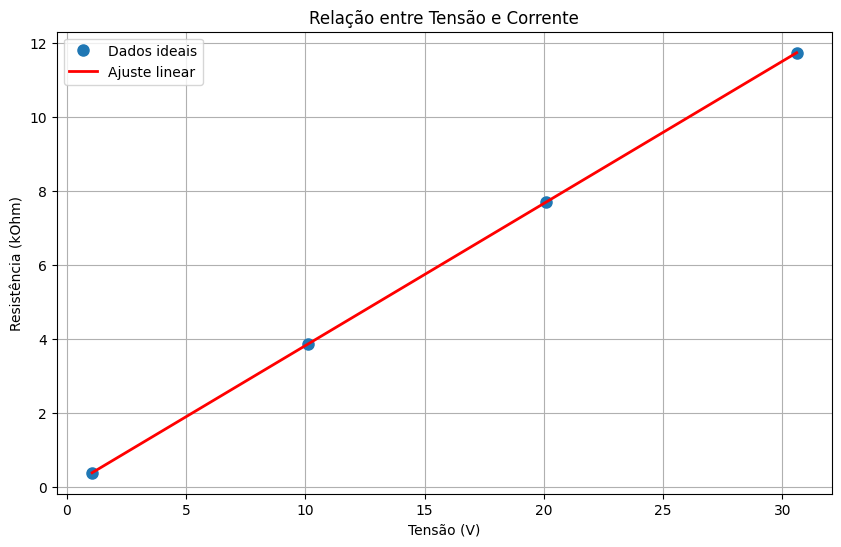

In [4]:
def f(x, A, B):
    return A * x + B

ydata = np.array(df['R(kOhm)'], dtype=float) 
xdata = np.array(df['V'], dtype=float)

popt, pcov = curve_fit(f, xdata, ydata)
A, B = popt
print(f'Coeficientes da reta: A = {A:.4f}, B = {B:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(xdata, ydata, 'o', label='Dados ideais', markersize=8)
plt.plot(xdata, f(xdata, *popt), 'r-', label='Ajuste linear', linewidth=2)
plt.title('Relação entre Tensão e Corrente')
plt.xlabel('Tensão (V)')
plt.ylabel('Resistência (kOhm)')
plt.grid()
plt.legend()
plt.show()

Resistência e aperagem obtidas de diversas voltagens:

In [5]:
Rexp = [0.387, 3.94, 7.84, 11.77] # kOhm 

Vexp = [1.06, 10.1, 20.1, 30.6] # V

i = [v/r for v, r in zip(Vexp, Rexp)]

df2 = pd.DataFrame({'V': Vexp, 'R(kOhm)': Rexp, 'I(mA)': i})
df2['I(mA)'] = df2['I(mA)'].apply(lambda x: f'{x:.4f}')

df2

,V,R(kOhm),I(mA)
0,1.06,0.387,2.7390
1,10.10,3.940,2.5635
2,20.10,7.840,2.5638
3,30.60,11.770,2.5998


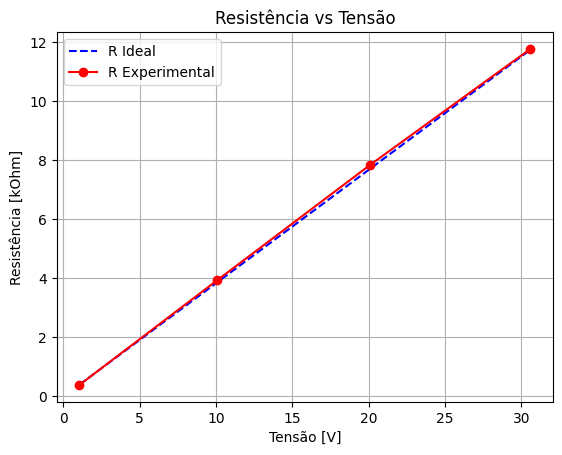

In [6]:
plt.plot(xdata, f(xdata, *popt), '--', label='R Ideal', color='blue')
plt.plot(df2['V'], df2['R(kOhm)'], 'o-', label='R Experimental', color='red')
plt.xlabel('Tensão [V]')
plt.ylabel('Resistência [kOhm]')
plt.title('Resistência vs Tensão')
plt.legend()
plt.grid()
plt.show()

---

# Amperímetro:

Características do Galvanômetro:

In [7]:
VG = 30.3 # mV
VG = VG * 1e-3 # V
RG = 11.9 # Ohm

IG = VG / RG # A

print(f'Corrente do Galvanômetro: {IG*1e3:.4f} mA')

Corrente do Galvanômetro: 2.5462 mA


Cálculo da resistência extra no circuito para poder medir determinada amperagem:

In [8]:
I_esperado = 1 # A

R_d = RG / ((I_esperado/(IG))-1) # Ohms

print(f'Resistência necessária: {R_d:.4f} Ohms para medir {I_esperado} A')

Resistência necessária: 0.0304 Ohms para medir 1 A


Resistência e amperagem obtidas em experimentos:

In [9]:
i_exp = [0.81, 1.08] # A

R_exp = [RG / ((i/(IG))-1) for i in i_exp]

df3 = pd.DataFrame({'I':i_exp, 'R':R_exp})
df3['R'] = df3['R'].apply(lambda x: f'{x:.4f}')

df3

,I,R
0,0.81,0.0375
1,1.08,0.0281


Resistência necessária para medir 1 A de acordo com os dados experimentais:

In [10]:
x = -((((i_exp[1]-I_esperado)/(i_exp[1]-i_exp[0])) * (R_exp[1]-R_exp[0]))-R_exp[1]) 

print(f'Resistência interpolada: {x:.4f} Ohms para medir {I_esperado} A')

Resistência interpolada: 0.0309 Ohms para medir 1 A
